# DNN PEAD — Trading Strategy Backtest

Buy when predicted class is 1 or 2 (DNN predictions). Exit at take-profit or t+10 close.

## Strategy 1 (2% Threshold)
Exit at 2% if stock reaches it, otherwise at t+10 close. Baseline strategy.

## Strategy 2 (Threshold Sweep)
Sweep 1%-5% (step 0.5%). Pick best threshold by Sharpe.

## Strategy 3 (Split-Sell)
Using best T from Strat 2. Sell a fraction at partial threshold,
remainder at full T or t+10. Tests split ratios: 70/30, 60/40, 50/50.

## Rules
- Initial capital: $50,000 · Position: $100 per trade
- Entry at t+1 close · Exit date from daily high crossing
- Return denominator = deployed capital (not total capital)


In [1]:
from pathlib import Path
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({"figure.dpi": 100, "font.size": 9})

In [2]:
# ── Paths (try repo-root relative first, then notebook-relative) ──────
RESULTS_PATH = Path("src/modeling/dnn_outputs/results.parquet")
if not RESULTS_PATH.exists():
    RESULTS_PATH = Path("dnn_outputs/results.parquet")

DAILY_PATH = Path("src/data/model_staging/tech_daily_table.parquet")
if not DAILY_PATH.exists():
    DAILY_PATH = Path("../data/model_staging/tech_daily_table.parquet")

# ── Strategy params ───────────────────────────────────────────────────
INITIAL_CAPITAL = 100000
POSITION_SIZE = 200
THRESHOLDS = np.arange(0.01, 0.0525, 0.005)  # 1% to 5%, step 0.5%

# ── Daily high window: t+2 to t+10 (9 trading days) ──────────────────
DRIFT_OFFSETS = list(range(2, 11))  # [2, 3, ..., 10]

---
## 1. Load & merge data

In [3]:
# ── Load results, filter to buy signals ───────────────────────────────
results = pl.read_parquet(RESULTS_PATH)
signals = results.filter(pl.col("target_class_predicted").is_in([1, 2]))
print(f"Buy signals: {len(signals):,}")

# ── Load daily OHLCV, add forward high/date/close columns ─────────────
daily = pl.read_parquet(DAILY_PATH).select(["symbol", "date", "high", "close"])
daily = daily.sort(["symbol", "date"])

# Forward shifts for drift window (t+2 .. t+10)
for offset in DRIFT_OFFSETS:
    daily = daily.with_columns([
        pl.col("high").shift(-offset).over("symbol").alias(f"high_t+{offset}"),
        pl.col("date").shift(-offset).over("symbol").alias(f"date_t+{offset}"),
    ])

# Entry date (t+1) and close at t+10
daily = daily.with_columns([
    pl.col("date").shift(-1).over("symbol").alias("entry_date"),
    pl.col("close").shift(-10).over("symbol").alias("close_t10"),
])

# ── Join drift + entry data onto signals ─────────────────────────────
join_cols = ["symbol", "date", "entry_date", "close_t10"]
for offset in DRIFT_OFFSETS:
    join_cols += [f"high_t+{offset}", f"date_t+{offset}"]

signals = signals.join(
    daily.select(join_cols),
    left_on=["symbol", "earnings_date"], right_on=["symbol", "date"], how="left",
)
signals = signals.with_columns(
    (pl.col("close_t10") / pl.col("entry_price") - 1).alias("close_t10_return")
)
print(f"After join — rows: {len(signals)}, null close_t10: {signals['close_t10_return'].null_count()}")

Buy signals: 8,221
After join — rows: 8221, null close_t10: 0


In [4]:
# ── Extract numpy arrays for vectorised threshold sweep ───────────────
HIGH_COLS = [f"high_t+{d}" for d in DRIFT_OFFSETS]
DATE_COLS = [f"date_t+{d}" for d in DRIFT_OFFSETS]

drift_highs = np.column_stack([signals[c].to_numpy() for c in HIGH_COLS])  # (N, 9)
drift_dates = np.column_stack([signals[c].to_numpy() for c in DATE_COLS])  # (N, 9)
entry_prices = signals["entry_price"].to_numpy()
close_t10_ret = signals["close_t10_return"].to_numpy()
close_t10_date = drift_dates[:, -1]
entry_dates = signals["entry_date"].to_numpy().astype("datetime64[D]")
N = len(signals)

# ── Cummax return during drift window per trade ───────────────────────
drift_rets = drift_highs / entry_prices[:, None] - 1
cummax_rets = np.maximum.accumulate(drift_rets, axis=1)

print(f"Ready — {N} trades, {len(DRIFT_OFFSETS)} drift days, {len(THRESHOLDS)} thresholds")

Ready — 8221 trades, 9 drift days, 9 thresholds


---
## 2. Signal Quality

In [5]:
buy_all = results.filter(pl.col("target_class_predicted").is_in([1, 2]))
overall_win = (buy_all["target_class_actual"] >= 1).mean()
print(f"Overall directional win % (actual >= 1): {overall_win:.2%}")
print(f"\n{'Pred':<6} {'Count':>7} {'Win% (≥1)':>11} {'Hit 2%':>8} {'AvgRet':>8}"
      f" {'Low(0)':>7} {'Mod(1)':>7} {'Str(2)':>7}")
print(f"{'-'*65}")
for p in [0, 1, 2]:
    sub = results.filter(pl.col("target_class_predicted") == p)
    win = (sub["target_class_actual"] >= 1).mean()
    hit2 = (sub["target_return_actual"] > 0.02).mean()
    a0, a1, a2 = [(sub["target_class_actual"] == c).sum() for c in [0, 1, 2]]
    print(f"{p:<6} {len(sub):>7,} {win:>11.2%} {hit2:>8.2%}"
          f" {sub['target_return_actual'].mean():>8.2%} {a0:>7} {a1:>7} {a2:>7}")

Overall directional win % (actual >= 1): 72.59%

Pred     Count   Win% (≥1)   Hit 2%   AvgRet  Low(0)  Mod(1)  Str(2)
-----------------------------------------------------------------
0        1,716      63.99%   63.99%    3.58%     618     504     594
1        2,290      67.07%   67.07%    3.77%     754     688     848
2        5,931      74.73%   74.73%    5.34%    1499    1395    3037


In [6]:
def compute_strat1_pnl(threshold):
    """Per-trade P&L + sell date at a single take-profit threshold."""
    crossed = cummax_rets > threshold
    first_idx = np.argmax(crossed, axis=1)
    did_cross = crossed[np.arange(N), first_idx]
    pnl = np.where(did_cross, threshold, close_t10_ret) * POSITION_SIZE
    sell_date = np.where(did_cross, drift_dates[np.arange(N), first_idx], close_t10_date)
    return pnl, sell_date


def filter_by_cash(pnl, sell_date, entry_date, initial_cap, pos_size):
    """Simulate entries+exits chronologically. Skips buys if cash < pos_size."""
    n = len(pnl)
    events = []
    for i in range(n):
        events.append((entry_date[i], "enter", i))
        events.append((sell_date[i], "exit", i))
    events.sort(key=lambda x: x[0])
    cash = initial_cap
    skipped = 0
    entered = set()
    for dt, etype, idx in events:
        if etype == "exit":
            if idx in entered:
                cash += pos_size + pnl[idx]  # return capital + P&L
        else:
            if cash >= pos_size:
                cash -= pos_size
                entered.add(idx)
            else:
                skipped += 1
    keep = np.sort(list(entered))
    return pnl[keep], sell_date[keep], entry_date[keep], skipped


def build_daily_equity(pnl, sell_date, initial_cap, entry_date=None, pos_size=None):
    """Aggregate P&L by sell date, compound equity curve.
    If entry_date + pos_size provided, uses deployed capital as denominator."""
    dates_py = sell_date.tolist()
    daily_pnl = pl.DataFrame({"sell_date": pl.Series(dates_py, dtype=pl.Date), "pnl": pnl})
    daily_pnl = daily_pnl.group_by("sell_date").agg(pl.sum("pnl")).sort("sell_date")
    dates = daily_pnl["sell_date"].to_numpy()
    pnl_vals = daily_pnl["pnl"].to_numpy()
    # Denominator: deployed capital if available, else initial
    if entry_date is not None and pos_size is not None:
        deployed = 0
        depl_lookup = {}
        for i in range(len(pnl)):
            d = sell_date[i]
            if d not in depl_lookup:
                # Count open positions on this day BEFORE exits
                depl_lookup[d] = 0
        # Walk chronologically to track deployed
        events = []
        for i in range(len(pnl)):
            events.append((entry_date[i], "enter"))
            events.append((sell_date[i], "exit"))
        events.sort(key=lambda x: x[0])
        for dt, etype in events:
            if etype == "enter":
                deployed += pos_size
            else:
                if dt in depl_lookup and depl_lookup[dt] == 0:
                    depl_lookup[dt] = deployed
                deployed -= pos_size
        denom = np.array([depl_lookup.get(d, initial_cap) for d in dates])
        denom = np.maximum(denom, pos_size)  # avoid div by zero
    else:
        denom = initial_cap
    daily_rets = pnl_vals / denom
    equity = initial_cap * (1 + daily_rets).cumprod()
    return dates, daily_rets, equity


def sharpe_annualised(daily_rets):
    if daily_rets.std() == 0:
        return 0.0
    return float(daily_rets.mean() / daily_rets.std() * np.sqrt(252))


# ── Run threshold sweep ───────────────────────────────────────────────
results_s1 = []
for T in THRESHOLDS:
    pnl, sell_date = compute_strat1_pnl(T)
    pnl, sell_date, entry_f, n_skipped = filter_by_cash(pnl, sell_date, entry_dates, INITIAL_CAPITAL, POSITION_SIZE)
    dates, daily_rets, equity = build_daily_equity(pnl, sell_date, INITIAL_CAPITAL, entry_f, POSITION_SIZE)
    sr = sharpe_annualised(daily_rets)
    total_pnl = pnl.sum()
    win_rate = (pnl > 0).mean()
    results_s1.append({
        "threshold": T, "sharpe": sr, "total_pnl": total_pnl,
        "win_rate": win_rate, "equity": equity, "dates": dates,
            "n_trades": len(pnl),
        "daily_rets": daily_rets, "n_skipped": n_skipped,
    })
    print(f"  T={T:4.1%}  Sharpe={sr:6.2f}  P&L=${total_pnl:>8,.0f}  Win={win_rate:5.1%}  Sk={n_skipped}")

  T=1.0%  Sharpe= -0.51  P&L=$   2,868  Win=86.2%  Sk=0
  T=1.5%  Sharpe= -0.45  P&L=$   4,921  Win=80.6%  Sk=0
  T=2.0%  Sharpe= -0.01  P&L=$   6,637  Win=75.9%  Sk=0
  T=2.5%  Sharpe=  0.30  P&L=$   7,903  Win=71.5%  Sk=0
  T=3.0%  Sharpe=  0.15  P&L=$   8,436  Win=67.5%  Sk=0
  T=3.5%  Sharpe=  0.31  P&L=$   9,531  Win=65.0%  Sk=0
  T=4.0%  Sharpe=  0.29  P&L=$  10,298  Win=63.0%  Sk=0
  T=4.5%  Sharpe=  0.21  P&L=$  11,311  Win=61.7%  Sk=0
  T=5.0%  Sharpe=  0.32  P&L=$  12,105  Win=60.7%  Sk=0


---
## 3. Strategy 1 — Fixed 2% Threshold


In [7]:
# Strat 1: fixed 2% take-profit
FIXED_T = 0.02
pnl_s1, sell_s1 = compute_strat1_pnl(FIXED_T)
pnl_s1, sell_s1, entry_s1, skipped_s1 = filter_by_cash(pnl_s1, sell_s1, entry_dates, INITIAL_CAPITAL, POSITION_SIZE)
dates_s1, daily_rets_s1, equity_s1 = build_daily_equity(pnl_s1, sell_s1, INITIAL_CAPITAL, entry_s1, POSITION_SIZE)
sr_s1 = sharpe_annualised(daily_rets_s1)
print(f"Strat 1 (T=2%):  Sharpe={sr_s1:.2f}  PnL=${pnl_s1.sum():,.0f}  Win={(pnl_s1>0).mean():.1%}  Skipped={skipped_s1}")


Strat 1 (T=2%):  Sharpe=-0.01  PnL=$6,637  Win=75.9%  Skipped=0


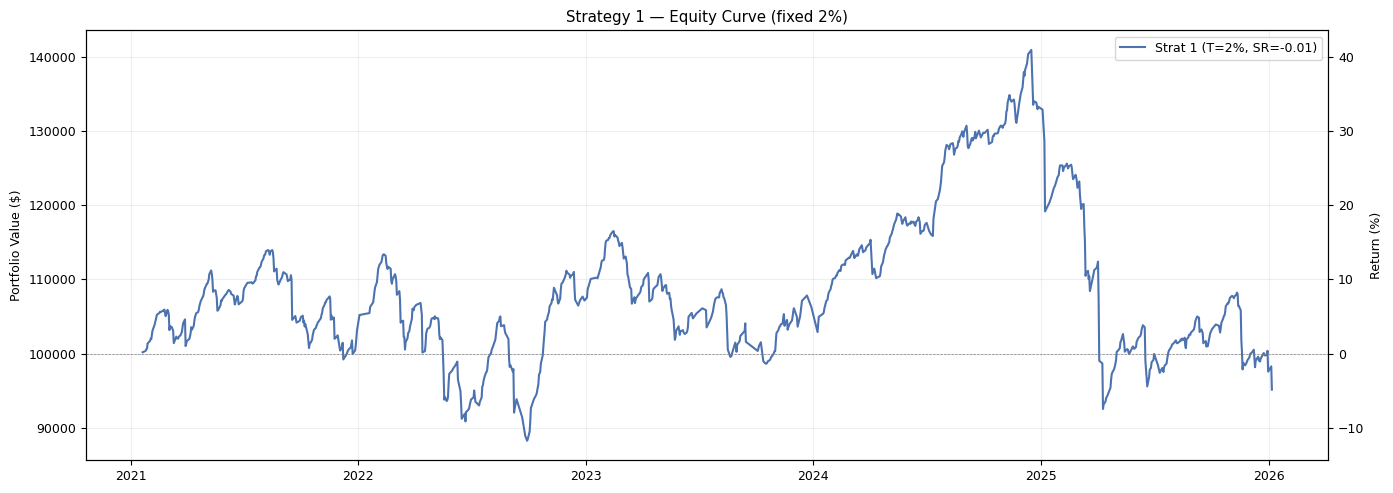

In [8]:
# Strat 1 — equity curve (fixed 2%)
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dates_s1, equity_s1, lw=1.5, color='#4C72B0', label=f'Strat 1 (T=2%, SR={sr_s1:.2f})')
ax.axhline(INITIAL_CAPITAL, color='gray', lw=0.5, ls='--')
ax.set_title("Strategy 1 — Equity Curve (fixed 2%)")
ax.set_ylabel("Portfolio Value ($)")
ax.legend(fontsize=9)
ax.grid(alpha=0.2)
axb = ax.twinx()
y0, y1 = ax.get_ylim()
axb.set_ylim(100*(y0/INITIAL_CAPITAL-1), 100*(y1/INITIAL_CAPITAL-1))
axb.set_ylabel("Return (%)")
plt.tight_layout()
plt.show()


---
## 4. Strategy 2 — Threshold Sweep (1%–5%)


In [9]:
def compute_strat1_pnl(threshold):
    """Per-trade P&L + sell date at a single take-profit threshold."""
    crossed = cummax_rets > threshold
    first_idx = np.argmax(crossed, axis=1)
    did_cross = crossed[np.arange(N), first_idx]
    pnl = np.where(did_cross, threshold, close_t10_ret) * POSITION_SIZE
    sell_date = np.where(did_cross, drift_dates[np.arange(N), first_idx], close_t10_date)
    return pnl, sell_date


def filter_by_cash(pnl, sell_date, entry_date, initial_cap, pos_size):
    """Simulate entries+exits chronologically. Skips buys if cash < pos_size."""
    n = len(pnl)
    events = []
    for i in range(n):
        events.append((entry_date[i], "enter", i))
        events.append((sell_date[i], "exit", i))
    events.sort(key=lambda x: x[0])
    cash = initial_cap
    skipped = 0
    entered = set()
    for dt, etype, idx in events:
        if etype == "exit":
            if idx in entered:
                cash += pos_size + pnl[idx]  # return capital + P&L
        else:
            if cash >= pos_size:
                cash -= pos_size
                entered.add(idx)
            else:
                skipped += 1
    keep = np.sort(list(entered))
    return pnl[keep], sell_date[keep], entry_date[keep], skipped


def build_daily_equity(pnl, sell_date, initial_cap, entry_date=None, pos_size=None):
    """Aggregate P&L by sell date, compound equity curve.
    If entry_date + pos_size provided, uses deployed capital as denominator."""
    dates_py = sell_date.tolist()
    daily_pnl = pl.DataFrame({"sell_date": pl.Series(dates_py, dtype=pl.Date), "pnl": pnl})
    daily_pnl = daily_pnl.group_by("sell_date").agg(pl.sum("pnl")).sort("sell_date")
    dates = daily_pnl["sell_date"].to_numpy()
    pnl_vals = daily_pnl["pnl"].to_numpy()
    # Denominator: deployed capital if available, else initial
    if entry_date is not None and pos_size is not None:
        deployed = 0
        depl_lookup = {}
        for i in range(len(pnl)):
            d = sell_date[i]
            if d not in depl_lookup:
                # Count open positions on this day BEFORE exits
                depl_lookup[d] = 0
        # Walk chronologically to track deployed
        events = []
        for i in range(len(pnl)):
            events.append((entry_date[i], "enter"))
            events.append((sell_date[i], "exit"))
        events.sort(key=lambda x: x[0])
        for dt, etype in events:
            if etype == "enter":
                deployed += pos_size
            else:
                if dt in depl_lookup and depl_lookup[dt] == 0:
                    depl_lookup[dt] = deployed
                deployed -= pos_size
        denom = np.array([depl_lookup.get(d, initial_cap) for d in dates])
        denom = np.maximum(denom, pos_size)  # avoid div by zero
    else:
        denom = initial_cap
    daily_rets = pnl_vals / denom
    equity = initial_cap * (1 + daily_rets).cumprod()
    return dates, daily_rets, equity


def sharpe_annualised(daily_rets):
    if daily_rets.std() == 0:
        return 0.0
    return float(daily_rets.mean() / daily_rets.std() * np.sqrt(252))


# ── Run threshold sweep ───────────────────────────────────────────────
results_s1 = []
for T in THRESHOLDS:
    pnl, sell_date = compute_strat1_pnl(T)
    pnl, sell_date, entry_f, n_skipped = filter_by_cash(pnl, sell_date, entry_dates, INITIAL_CAPITAL, POSITION_SIZE)
    dates, daily_rets, equity = build_daily_equity(pnl, sell_date, INITIAL_CAPITAL, entry_f, POSITION_SIZE)
    sr = sharpe_annualised(daily_rets)
    total_pnl = pnl.sum()
    win_rate = (pnl > 0).mean()
    results_s1.append({
        "threshold": T, "sharpe": sr, "total_pnl": total_pnl,
        "win_rate": win_rate, "equity": equity, "dates": dates,
            "n_trades": len(pnl),
        "daily_rets": daily_rets, "n_skipped": n_skipped,
    })
    print(f"  T={T:4.1%}  Sharpe={sr:6.2f}  P&L=${total_pnl:>8,.0f}  Win={win_rate:5.1%}  Sk={n_skipped}")

  T=1.0%  Sharpe= -0.51  P&L=$   2,868  Win=86.2%  Sk=0
  T=1.5%  Sharpe= -0.45  P&L=$   4,921  Win=80.6%  Sk=0
  T=2.0%  Sharpe= -0.01  P&L=$   6,637  Win=75.9%  Sk=0
  T=2.5%  Sharpe=  0.30  P&L=$   7,903  Win=71.5%  Sk=0
  T=3.0%  Sharpe=  0.15  P&L=$   8,436  Win=67.5%  Sk=0
  T=3.5%  Sharpe=  0.31  P&L=$   9,531  Win=65.0%  Sk=0
  T=4.0%  Sharpe=  0.29  P&L=$  10,298  Win=63.0%  Sk=0
  T=4.5%  Sharpe=  0.21  P&L=$  11,311  Win=61.7%  Sk=0
  T=5.0%  Sharpe=  0.32  P&L=$  12,105  Win=60.7%  Sk=0


In [10]:
# target_return_actual from results vs cummax of drift_highs
max_from_drift = cummax_rets[:, -1]  # max across all 9 days
actual_from_results = signals["target_return_actual"].to_numpy()

diff = np.abs(max_from_drift - actual_from_results)
print(f"Max difference: {diff.max():.6f}")
print(f"Mismatched rows: {(diff > 0.001).sum()}")

Max difference: 0.000000
Mismatched rows: 0


In [11]:
# What fraction of trades actually exceed 18%?
print(f"Fraction > 18%: {(signals['target_return_actual'] > 0.18).mean():.2%}")

Fraction > 18%: 1.95%


In [12]:
# ── Select best threshold by Sharpe ───────────────────────────────────
best_idx = max(range(len(results_s1)), key=lambda i: results_s1[i]["sharpe"])
best = results_s1[best_idx]
BEST_T = best["threshold"]
print(f"\nBest threshold: {BEST_T:.1%}  (Sharpe: {best['sharpe']:.2f}, "
      f"P&L: ${best['total_pnl']:,.0f}, Skipped: {best['n_skipped']})")


Best threshold: 5.0%  (Sharpe: 0.32, P&L: $12,105, Skipped: 0)


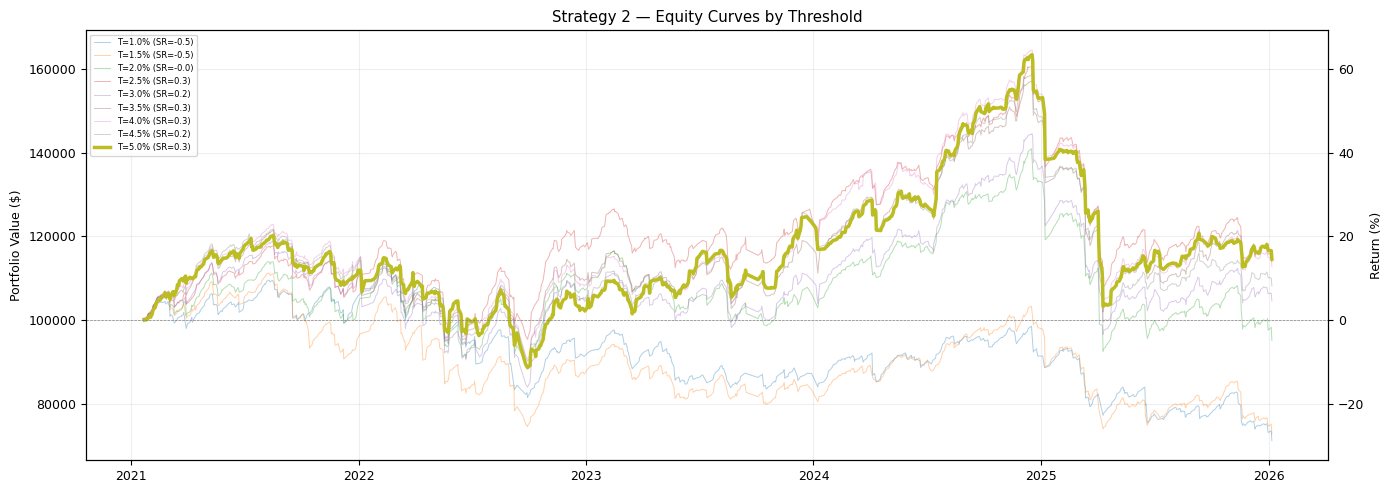

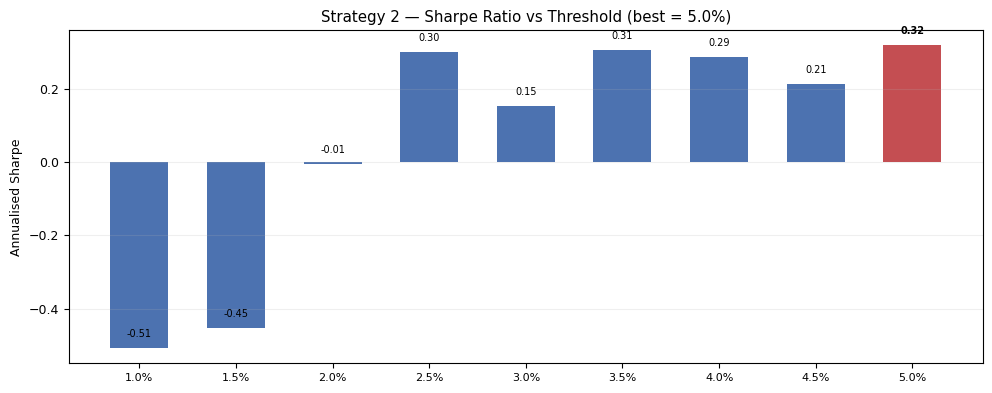

In [13]:
# Strat 2 — Equity curves overlay (all thresholds)
fig, ax1 = plt.subplots(figsize=(14, 5))

for r in results_s1:
    
    label = f"T={r['threshold']:.1%} (SR={r['sharpe']:.1f})"
    lw = 2.5 if r["threshold"] == BEST_T else 0.7
    alpha = 1.0 if r["threshold"] == BEST_T else 0.35
    ax1.plot(r["dates"], r["equity"], label=label, lw=lw, alpha=alpha)

ax1.axhline(INITIAL_CAPITAL, color="gray", lw=0.5, ls="--")
ax1.set_title("Strategy 2 — Equity Curves by Threshold")
ax1.set_ylabel("Portfolio Value ($)")
ax1.legend(fontsize=6, loc="upper left")
ax1.grid(alpha=0.2)
ax1b = ax1.twinx()
y0, y1 = ax1.get_ylim()
ax1b.set_ylim(100*(y0/INITIAL_CAPITAL-1), 100*(y1/INITIAL_CAPITAL-1))
ax1b.set_ylabel("Return (%)")
plt.tight_layout()
plt.show()

# Strat 2 — Sharpe vs Threshold bar chart
fig2, ax2 = plt.subplots(figsize=(10, 4))
T_list = [r["threshold"] for r in results_s1]
sr_list = [r["sharpe"] for r in results_s1]
pnl_list = [r["total_pnl"] for r in results_s1]
colors = ["#4C72B0" if i != best_idx else "#C44E52" for i in range(len(results_s1))]
ax2.bar(range(len(T_list)), sr_list, color=colors, width=0.6)
ax2.set_xticks(range(len(T_list)))
ax2.set_xticklabels([f"{t:.1%}" for t in T_list], fontsize=8)
ax2.set_title(f"Strategy 2 — Sharpe Ratio vs Threshold (best = {BEST_T:.1%})")
ax2.set_ylabel("Annualised Sharpe")
ax2.grid(alpha=0.2, axis="y")
for i, sr in enumerate(sr_list):
    ax2.text(i, sr + 0.03, f"{sr:.2f}", ha="center", fontsize=7,
             fontweight="bold" if i == best_idx else "normal")
plt.tight_layout()
plt.show()


---
## 3b. Yearly & Quarterly Summary (Best Threshold)


In [14]:
# Build per-trade DataFrame for the best threshold
pnl_best, sell_date_best = compute_strat1_pnl(BEST_T)
pnl_best, sell_date_best, entry_best, _ = filter_by_cash(pnl_best, sell_date_best, entry_dates, INITIAL_CAPITAL, POSITION_SIZE)

trades_best = pl.DataFrame({
    "sell_date": sell_date_best.tolist(),
    "pnl": pnl_best,
}).with_columns(
    pl.col("sell_date").cast(pl.Date),
    pl.col("sell_date").dt.year().alias("year"),
    pl.col("sell_date").dt.quarter().alias("quarter"),
    (pl.col("pnl") > 0).alias("is_win"),
)

# Yearly summary
yearly = trades_best.group_by("year").agg([
    pl.len().alias("trades"),
    pl.sum("pnl").alias("total_pnl"),
    pl.mean("pnl").alias("avg_pnl"),
    pl.mean("is_win").alias("win_rate"),
]).sort("year")

print("Year  Trades    P&L ($)   Avg P&L  Win Rate")
print("-" * 48)
for row in yearly.iter_rows():
    yr, n, pnl_val, avg, wr = row
    print(f"{yr:<6} {n:>5} {pnl_val:>+10,.0f} {avg:>+9.2f} {wr:>9.1%}")

# Quarterly summary
quarterly = trades_best.group_by(["year", "quarter"]).agg([
    pl.len().alias("trades"),
    pl.sum("pnl").alias("total_pnl"),
    pl.mean("pnl").alias("avg_pnl"),
    pl.mean("is_win").alias("win_rate"),
]).sort(["year", "quarter"])

quarterly = quarterly.with_columns(
    (pl.col("year").cast(pl.Utf8) + " Q" + pl.col("quarter").cast(pl.Utf8)).alias("label"),
    pl.col("total_pnl").cum_sum().alias("cum_pnl"),
)

print("\nQuarter   Trades     P&L ($)  Cum P&L   Avg P&L  Win Rate")
print("-" * 64)
for row in quarterly.iter_rows():
    yr, q, n, pnl_val, avg, wr, label, cum = row
    print(f"{label:<10} {n:>5} {pnl_val:>+10,.0f} {cum:>+10,.0f} {avg:>+9.2f} {wr:>9.1%}")

Year  Trades    P&L ($)   Avg P&L  Win Rate
------------------------------------------------
2021    1622     +2,984     +1.84     61.5%
2022    1791     +1,662     +0.93     60.4%
2023    1294     +1,393     +1.08     56.6%
2024    1666     +4,552     +2.73     66.1%
2025    1842     +1,525     +0.83     58.3%
2026       6        -11     -1.89     33.3%

Quarter   Trades     P&L ($)  Cum P&L   Avg P&L  Win Rate
----------------------------------------------------------------
2021 Q1      477     +1,481     +1,481     +3.10     68.8%
2021 Q2      385       +527     +2,008     +1.37     57.7%
2021 Q3      485       +612     +2,620     +1.26     59.2%
2021 Q4      275       +364     +2,984     +1.32     58.2%
2022 Q1      485       +140     +3,124     +0.29     56.3%
2022 Q2      483     -2,292       +832     -4.75     36.2%
2022 Q3      328     +1,159     +1,991     +3.53     74.1%
2022 Q4      495     +2,655     +4,646     +5.36     78.8%
2023 Q1      487       -298     +4,348     -0.6

---
## 5. Strategy 3 — Split-Sell Exit

Using best T from Strat 2. Sell a fraction at (split_pct × T),
remainder at full T (or t+10 if never hit). Tests 70/30, 60/40, 50/50.


In [15]:
# Split-sell: sell frac at (frac * BEST_T), rest at BEST_T or t+10
SPLIT_RATIOS = [0.7, 0.6, 0.5]

full_crossed = cummax_rets > BEST_T
f_idx = np.argmax(full_crossed, axis=1)
f_did = full_crossed[np.arange(N), f_idx]

strat3_results = []
for frac in SPLIT_RATIOS:
    partial_T = BEST_T * frac
    amt_first = POSITION_SIZE * frac
    amt_rest = POSITION_SIZE - amt_first

    pcrossed = cummax_rets > partial_T
    p_idx = np.argmax(pcrossed, axis=1)
    p_did = pcrossed[np.arange(N), p_idx]

    pnl_list2, sell_list2, entry_list2 = [], [], []
    for i in range(N):
        if p_did[i]:
            entry_list2.append(entry_dates[i])
            pnl_list2.append(amt_first * partial_T)
            sell_list2.append(drift_dates[i, p_idx[i]])
            if f_did[i]:
                entry_list2.append(entry_dates[i])
                pnl_list2.append(amt_rest * BEST_T)
                sell_list2.append(drift_dates[i, f_idx[i]])
            else:
                entry_list2.append(entry_dates[i])
                pnl_list2.append(amt_rest * close_t10_ret[i])
                sell_list2.append(close_t10_date[i])
        else:
            entry_list2.append(entry_dates[i])
            pnl_list2.append(POSITION_SIZE * close_t10_ret[i])
            sell_list2.append(close_t10_date[i])

    pnl_arr = np.array(pnl_list2)
    sell_arr = np.array(sell_list2)
    entry_arr = np.array(entry_list2)

    pnl_arr, sell_arr, entry_arr, skipped = filter_by_cash(pnl_arr, sell_arr, entry_arr, INITIAL_CAPITAL, amt_first)
    dates, daily_rets, equity = build_daily_equity(pnl_arr, sell_arr, INITIAL_CAPITAL, entry_arr, amt_first)
    sr = sharpe_annualised(daily_rets)

    lbl = f"{int(frac*100)}/{int((1-frac)*100)}"
    strat3_results.append(dict(split=lbl, frac=frac, sharpe=sr, total_pnl=pnl_arr.sum(),
        win_rate=(pnl_arr>0).mean(), equity=equity, dates=dates, n_exits=len(pnl_arr), skipped=skipped))
    print(f"  Split {lbl}: Sharpe={sr:.2f}  PnL=${pnl_arr.sum():,.0f}  Win={(pnl_arr>0).mean():.1%}")


  Split 70/30: Sharpe=-0.71  PnL=$10,303  Win=74.3%
  Split 60/40: Sharpe=-0.74  PnL=$9,904  Win=75.2%
  Split 50/50: Sharpe=-0.51  PnL=$10,004  Win=76.3%


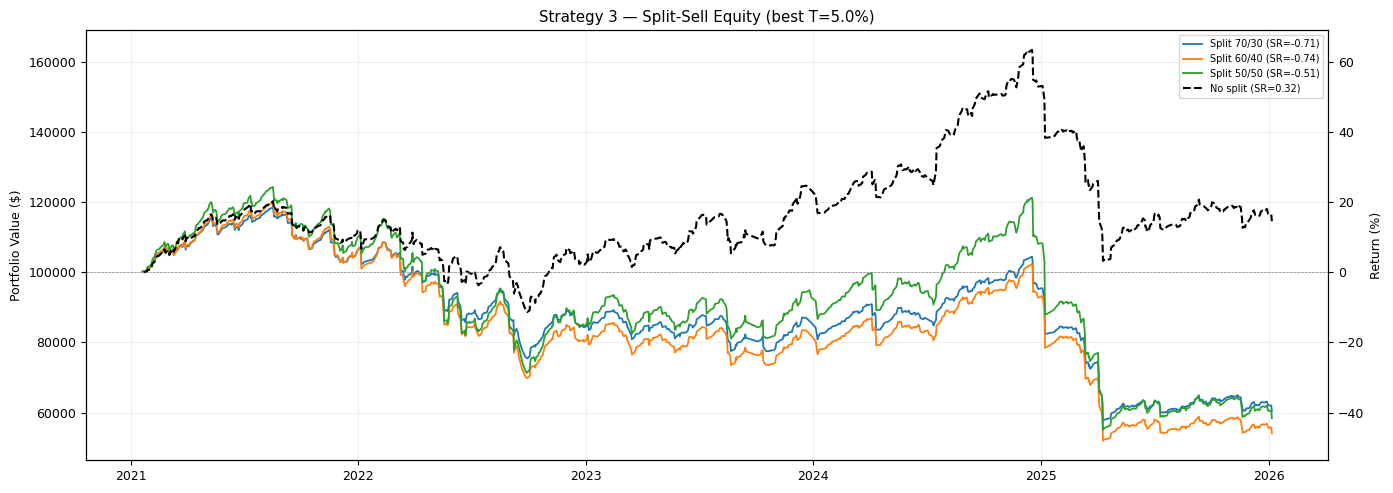

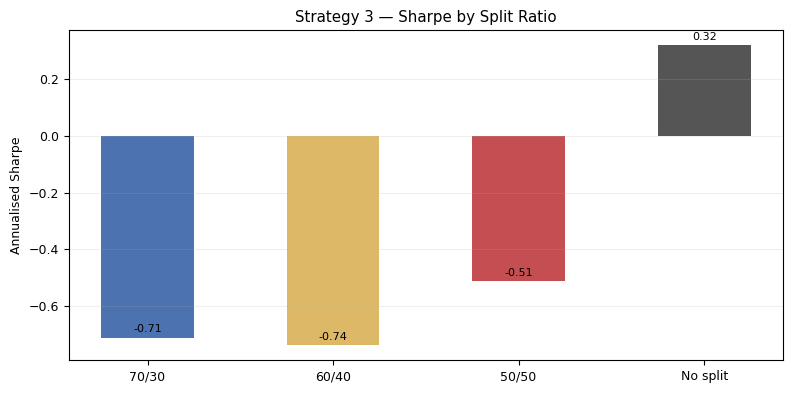

In [16]:
# Strat 3 — Equity curves overlay by split ratio
fig1, ax1 = plt.subplots(figsize=(14, 5))
for r in strat3_results:
    ax1.plot(r["dates"], r["equity"], lw=1.3, label=f"Split {r["split"]} (SR={r["sharpe"]:.2f})")
ax1.plot(best["dates"], best["equity"], "k--", lw=1.5, label=f"No split (SR={best["sharpe"]:.2f})")
ax1.axhline(INITIAL_CAPITAL, color="gray", lw=0.5, ls="--")
ax1.set_title(f"Strategy 3 — Split-Sell Equity (best T={BEST_T:.1%})")
ax1.set_ylabel("Portfolio Value ($)")
ax1.legend(fontsize=7)
ax1.grid(alpha=0.2)
ax1b = ax1.twinx()
y0, y1 = ax1.get_ylim()
ax1b.set_ylim(100*(y0/INITIAL_CAPITAL-1), 100*(y1/INITIAL_CAPITAL-1))
ax1b.set_ylabel("Return (%)")
plt.tight_layout()
plt.show()

# Strat 3 — Sharpe by split ratio + No split comparison
fig2, ax2 = plt.subplots(figsize=(8, 4))
labels = [r["split"] for r in strat3_results] + ["No split"]
sr_vals = [r["sharpe"] for r in strat3_results] + [best["sharpe"]]
colors = ["#4C72B0", "#DDB967", "#C44E52", "#555555"]
ax2.bar(range(len(labels)), sr_vals, color=colors, width=0.5)
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels)
ax2.set_title("Strategy 3 — Sharpe by Split Ratio")
ax2.set_ylabel("Annualised Sharpe")
ax2.grid(alpha=0.2, axis="y")
for i, sr in enumerate(sr_vals):
    ax2.text(i, sr + 0.02, f"{sr:.2f}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()


---
## Notes

- **Daily return** = (sum of P&L from trades closing today) / initial capital.
  Then equity compounds: `equity × (1 + return)` each active day, flat on inactive days.
- **Cash filter**: Trades are processed in entry-date order. If cash drops below
  `POSITION_SIZE`, subsequent trades are skipped (counted in `Sk` column).
  With $100/position and $50K capital, zero trades skip (max ~500 concurrent).
- **Sell dates** are exact — `date_t+{offset}` columns from daily OHLCV give
  actual calendar sell dates at the crossing day.
- **% Return**: right axis is scaled to match the dollar axis — 0% = $50K,
  10% = $55K, etc.
- **No slippage or commissions** are modeled. Add ~5-10 bps per trade for realism.